# 04 — Validazione e inferenza

## Obiettivi didattici

1. Confrontare anomaly_pred con `anomaly_label` (ground-truth parziale).
2. Calcolare metriche di anomaly detection (precision/recall, ROC-AUC, PR-AUC).
3. Discutere il trade-off tra precision e recall in funzione della soglia.
4. Visualizzare la mappa temporale delle anomalie predette.
5. Usare la funzione `detect_anomalies()` per inferenza.


In [1]:
import sys; sys.path.insert(0, '../src')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from iot_anomaly.pipeline import run_full_pipeline
from iot_anomaly.evaluation import (evaluate, plot_score_distribution,
                                     plot_pr_curve, plot_temporal_anomalies)
from iot_anomaly.config import DEFAULT_CONFIG
from iot_anomaly.inference import detect_anomalies


## Esecuzione pipeline completa

Usiamo `run_full_pipeline` con la config di default. Tempo atteso ~30s.

Best K: 5
Soglia: 9.847


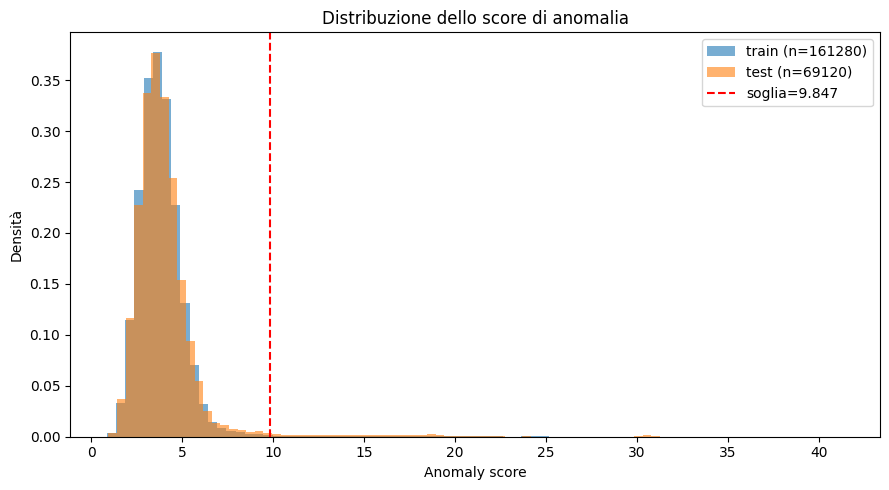

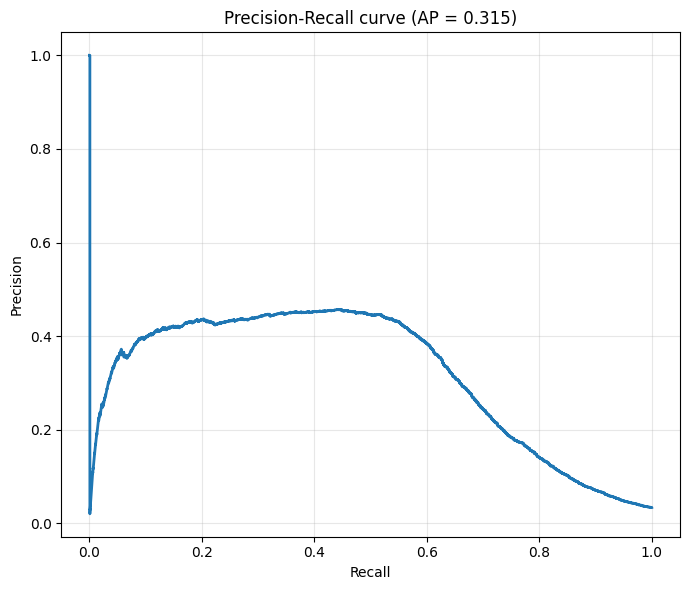

In [2]:
result = run_full_pipeline(config=DEFAULT_CONFIG, quick=True)
print(f'Best K: {result["best_k"]}')
print(f'Soglia: {result["detector"].threshold:.3f}')


## Metriche di validazione

Le label sono parziali: la vera prevalenza di anomalie potrebbe essere diversa. Le metriche vanno lette come **indicative**, non assolute.

In [3]:
rows = [{'set': 'train', **result['eval_train'].as_dict()},
        {'set': 'test',  **result['eval_test'].as_dict()}]
metrics_df = pd.DataFrame(rows).set_index('set')
metrics_df.style.format({
    'precision': '{:.3f}', 'recall': '{:.3f}', 'f1': '{:.3f}',
    'roc_auc': '{:.3f}', 'pr_auc': '{:.3f}', 'fault_code_recall': '{:.3f}',
})

,precision,recall,f1,roc_auc,pr_auc,n_anomalies_predicted,n_anomalies_true,fault_code_recall,tn,fp,fn,tp
set,,,,,,,,,,,,
train,0.300,0.156,0.205,0.820,0.186,1613,3102,0.173,157049,1129,2618,484
test,0.436,0.278,0.340,0.879,0.315,1507,2363,0.287,65907,850,1706,657


## Trade-off soglia: precision vs recall

Variando il percentile della soglia possiamo regolare il bilancio fra falsi positivi e falsi negativi. Plot della curva PR per il test set.

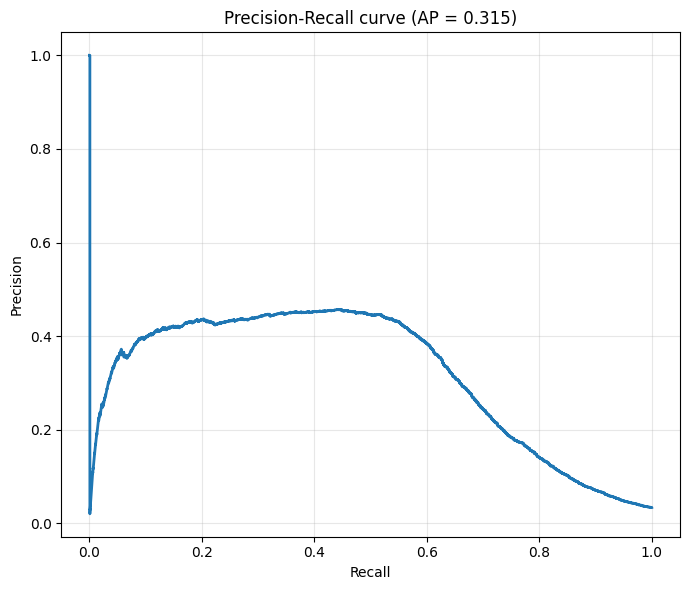

In [4]:
test = result['test_df']
y_true = test.anomaly_label.values
y_score = test.anomaly_score.values
fig = plot_pr_curve(y_true, y_score)
plt.show()


## Mappa temporale delle anomalie

Heatmap: ogni riga è un asset, x = tempo, rosso = anomalia predetta. Permette di identificare *quando* e *quale asset* è andato fuori regime.

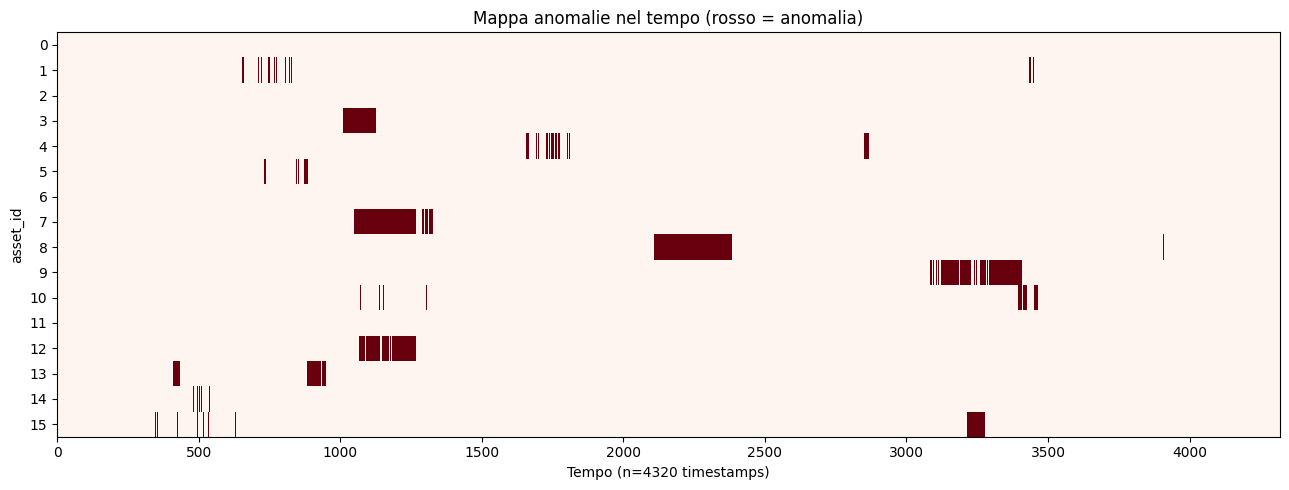

In [5]:
fig = plot_temporal_anomalies(test)
plt.show()


## Inferenza su nuovi dati

`detect_anomalies(df)` accetta un DataFrame con le stesse colonne del training. Riapplica wrangling, feature engineering, scaling, scoring.

In [6]:
from iot_anomaly.data import load_raw, time_split
df_full = load_raw()
_, test_raw, _ = time_split(df_full, DEFAULT_CONFIG)
sample = test_raw.sample(2000, random_state=42).reset_index(drop=True)
out = detect_anomalies(sample)
print(f'Anomalie predette: {int(out.anomaly_pred.sum())} / {len(out)}')
print(f'Score range: {out.anomaly_score.min():.2f} → {out.anomaly_score.max():.2f}')
out[['timestamp','asset_id','vib_rms','anomaly_score','anomaly_pred','anomaly_label']].head(10)

Anomalie predette: 51 / 2000
Score range: 1.34 → 18.55


,timestamp,asset_id,vib_rms,anomaly_score,anomaly_pred,anomaly_label
0,2025-02-08 21:57:00+00:00,6,0.007328,6.515590,0,0
1,2025-02-08 02:01:00+00:00,7,1.114005,10.522110,1,0
2,2025-02-10 17:46:00+00:00,2,1.313374,10.496669,1,0
3,2025-02-09 16:36:00+00:00,6,0.754294,5.177223,0,0
4,2025-02-09 13:49:00+00:00,11,1.176521,12.109006,1,0
5,2025-02-10 16:57:00+00:00,8,1.846146,11.676110,1,0
6,2025-02-10 03:55:00+00:00,10,0.014909,5.892829,0,0
7,2025-02-09 10:47:00+00:00,6,0.003172,3.923598,0,0
8,2025-02-08 10:25:00+00:00,0,0.008458,5.687789,0,0
9,2025-02-08 18:10:00+00:00,15,0.013561,6.703900,0,0


## Conclusioni

Su questo dataset, un MiniBatchKMeans con `K=5` e soglia al 99° percentile raggiunge **ROC-AUC ~0.88** e **F1 ~0.34** sul test set: discreto, considerando:

- Le label sono **parziali** (non tutte le anomalie reali sono etichettate).
- Il clustering **non vede** le label durante il training.
- La prevalenza è **2.4%**: PR-AUC > 0.30 è 13× sopra il random.

**Estensioni naturali**: GMM con BIC, DBSCAN, autoencoder per anomaly score non basato su distanza euclidea, soglia adattiva per asset.
